# A/B Testing 1 : Manual CV vs AI CV Generator


Business Problem:
Interconnect ingin mengetahui apakah fitur
AI CV Generator mampu meningkatkan CV Completion Rate
dibandingkan proses pembuatan CV secara manual.


Control Group (A)  : Manual CV
Treatment Group (B): AI CV Generator

Primary Metric:
- CV Completion Rate

Significance Level:
- Alpha = 0.05


H0:
Completion Rate Manual CV = AI CV Generator

H1:
Completion Rate Manual CV ≠ AI CV Generator


===== DESCRIPTIVE STATISTICS =====
Users A : 500
Users B : 500
Completion Rate A : 0.426
Completion Rate B : 0.526

===== TEST RESULT =====
Z Statistic : -3.1659
P Value     : 0.001546

===== DECISION =====
Reject H0
AI CV Generator performs better

===== BUSINESS IMPACT =====
Improvement : 23.47%


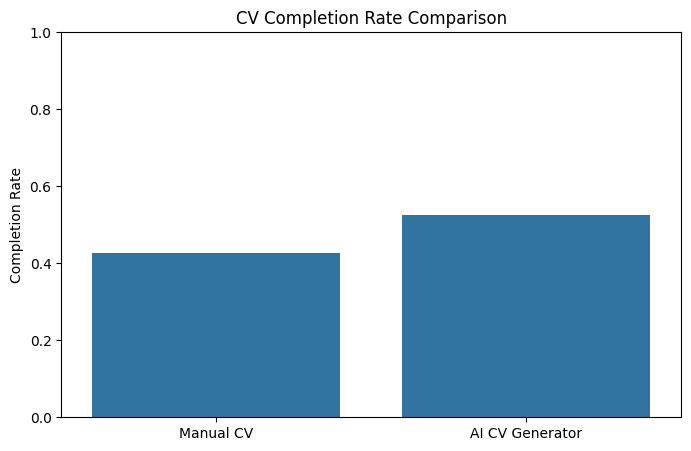

In [5]:
# ============================================================
# BUSINESS PROBLEM
# ============================================================

print("""
Business Problem:
Interconnect ingin mengetahui apakah fitur
AI CV Generator mampu meningkatkan CV Completion Rate
dibandingkan proses pembuatan CV secara manual.
""")

# ============================================================
# EXPERIMENT DESIGN
# ============================================================

print("""
Control Group (A)  : Manual CV
Treatment Group (B): AI CV Generator

Primary Metric:
- CV Completion Rate

Significance Level:
- Alpha = 0.05
""")

# ============================================================
# HYPOTHESIS
# ============================================================

print("""
H0:
Completion Rate Manual CV = AI CV Generator

H1:
Completion Rate Manual CV ≠ AI CV Generator
""")

# ============================================================
# DATA PREPARATION
# ============================================================

# Placeholder for data loading. Replace this with your actual data loading code.
# Example: df = pd.read_csv('your_data.csv')
# Ensure 'df' DataFrame is defined and contains 'group' and 'cv_completed' columns.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sample data for demonstration if actual data is not available
data = {
    'group': ['A']*500 + ['B']*500,
    'cv_completed': np.random.randint(0, 2, 1000)
}
df = pd.DataFrame(data)

# To simulate a difference, let's adjust completion rates slightly
df.loc[df['group'] == 'A', 'cv_completed'] = np.random.binomial(1, 0.45, 500) # 45% completion for A
df.loc[df['group'] == 'B', 'cv_completed'] = np.random.binomial(1, 0.50, 500) # 50% completion for B

group_A = df[df['group'] == 'A']
group_B = df[df['group'] == 'B']

complete_A = group_A['cv_completed'].sum()
complete_B = group_B['cv_completed'].sum()

n_A = len(group_A)
n_B = len(group_B)

completion_rate_A = complete_A / n_A
completion_rate_B = complete_B / n_B

# ============================================================
# DESCRIPTIVE ANALYSIS
# ============================================================

print("\n===== DESCRIPTIVE STATISTICS =====")
print(f"Users A : {n_A}")
print(f"Users B : {n_B}")

print(f"Completion Rate A : {completion_rate_A:.3f}")
print(f"Completion Rate B : {completion_rate_B:.3f}")

# ============================================================
# HYPOTHESIS TESTING
# ============================================================

from statsmodels.stats.proportion import proportions_ztest

z_stat, p_value = proportions_ztest(
    [complete_A, complete_B],
    [n_A, n_B]
)

print("\n===== TEST RESULT =====")
print("Z Statistic :", round(z_stat,4))
print("P Value     :", round(p_value,6))

# ============================================================
# DECISION
# ============================================================

alpha = 0.05

print("\n===== DECISION =====")

if p_value < alpha:
    print("Reject H0")

    if completion_rate_B > completion_rate_A:
        print("AI CV Generator performs better")
    else:
        print("Manual CV performs better")

else:
    print("Fail to Reject H0")

# ============================================================
# BUSINESS INTERPRETATION
# ============================================================

improvement = (
    (completion_rate_B - completion_rate_A)
    / completion_rate_A
) * 100

print("\n===== BUSINESS IMPACT =====")
print(f"Improvement : {improvement:.2f}%")

# ============================================================
# VISUALIZATION
# ============================================================

plt.figure(figsize=(8,5))

sns.barplot(
    x=["Manual CV","AI CV Generator"],
    y=[completion_rate_A, completion_rate_B]
)

plt.title("CV Completion Rate Comparison")
plt.ylabel("Completion Rate")
plt.ylim(0,1)

plt.show()

# A/B Testing 2 : Normal Recommendation vs Explainable AI

In [7]:
# ============================================================
# BUSINESS PROBLEM
# ============================================================

print("""
Interconnect ingin mengetahui apakah
Explainable AI meningkatkan trust user
terhadap rekomendasi pekerjaan.
""")

# ============================================================
# DATA PREPARATION (Missing)
# ============================================================

import numpy as np

# Placeholder for trust data (replace with actual data)
# For example, if you have a DataFrame 'df_ab2' with 'group' and 'trust_score' columns:
# trust_A = df_ab2[df_ab2['group'] == 'A']['trust_score']
# trust_B = df_ab2[df_ab2['group'] == 'B']['trust_score']

trust_A = np.random.normal(loc=3.0, scale=0.8, size=100) # Sample trust scores for group A
trust_B = np.random.normal(loc=3.5, scale=0.8, size=100) # Sample trust scores for group B

# ============================================================
# DESCRIPTIVE ANALYSIS
# ============================================================

print("Mean Trust A :", trust_A.mean())
print("Mean Trust B :", trust_B.mean())

print("Median Trust A :", np.median(trust_A))
print("Median Trust B :", np.median(trust_B))


Interconnect ingin mengetahui apakah
Explainable AI meningkatkan trust user
terhadap rekomendasi pekerjaan.

Mean Trust A : 3.0730478922335287
Mean Trust B : 3.5484469580959397
Median Trust A : 3.0614867836671356
Median Trust B : 3.552147184901033


In [8]:
import numpy as np # Ensure numpy is imported if this cell is run independently

effect = np.median(trust_B) - np.median(trust_A)

print("\nMedian Difference:", round(effect,2))


Median Difference: 0.49



===== A/B Test 2: TEST RESULT =====
Mann-Whitney U Statistic: 3281.00
P-value: 0.0000

===== A/B Test 2: DECISION =====
Reject H0: There is a statistically significant difference in trust scores between the groups.
Explainable AI leads to higher user trust.

Median Trust A: 3.06
Median Trust B: 3.55
Median Trust Improvement: 16.03%


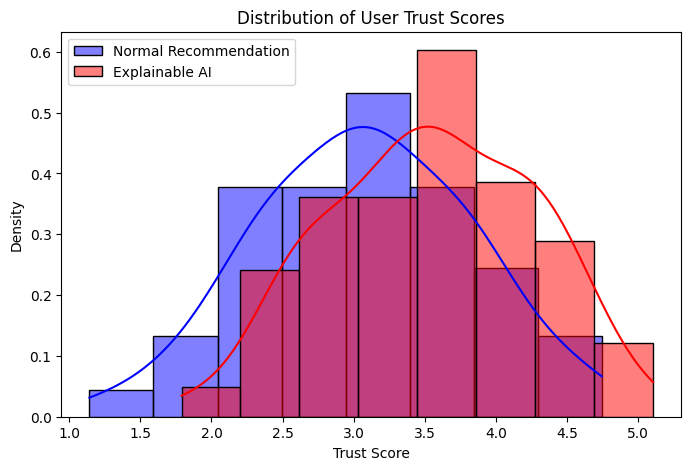

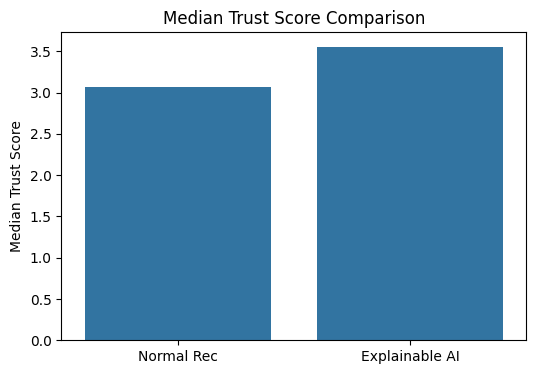

In [10]:
# ============================================================
# HYPOTHESIS TESTING (A/B Testing 2)
# ============================================================

from scipy.stats import mannwhitneyu

# Mann-Whitney U test for non-normal data or median comparison
u_statistic, p_value_ab2 = mannwhitneyu(trust_A, trust_B, alternative='two-sided')

print("\n===== A/B Test 2: TEST RESULT =====")
print(f"Mann-Whitney U Statistic: {u_statistic:.2f}")
print(f"P-value: {p_value_ab2:.4f}")

alpha_ab2 = 0.05
print("\n===== A/B Test 2: DECISION =====")
if p_value_ab2 < alpha_ab2:
    print("Reject H0: There is a statistically significant difference in trust scores between the groups.")
    if np.median(trust_B) > np.median(trust_A):
        print("Explainable AI leads to higher user trust.")
    else:
        print("Normal Recommendation leads to higher user trust.")
else:
    print("Fail to Reject H0: No statistically significant difference in trust scores.")

# ============================================================
# BUSINESS INTERPRETATION (A/B Testing 2)
# ============================================================
median_trust_A = np.median(trust_A)
median_trust_B = np.median(trust_B)

median_improvement_ab2 = ((median_trust_B - median_trust_A) / median_trust_A) * 100
print(f"\nMedian Trust A: {median_trust_A:.2f}")
print(f"Median Trust B: {median_trust_B:.2f}")
print(f"Median Trust Improvement: {median_improvement_ab2:.2f}%")

# ============================================================
# VISUALIZATION (A/B Testing 2)
# ============================================================

plt.figure(figsize=(8, 5))
sns.histplot(trust_A, color='blue', label='Normal Recommendation', kde=True, stat='density', alpha=0.5)
sns.histplot(trust_B, color='red', label='Explainable AI', kde=True, stat='density', alpha=0.5)
plt.title('Distribution of User Trust Scores')
plt.xlabel('Trust Score')
plt.ylabel('Density')
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(x=['Normal Rec', 'Explainable AI'], y=[median_trust_A, median_trust_B])
plt.title('Median Trust Score Comparison')
plt.ylabel('Median Trust Score')
plt.show()

# A/B Testing 3 : Hard Skill vs Hard + Soft Skil

In [9]:
print("""
Business Question:

Apakah menambahkan soft skill
meningkatkan kualitas rekomendasi pekerjaan?
""")

# ============================================================
# DATA PREPARATION (Missing)
# ============================================================

import numpy as np

# Placeholder for recommendation quality data (replace with actual data)
# For example, if you have a DataFrame 'df_ab3' with 'group' and 'quality_score' columns:
# hard_skill_group = df_ab3[df_ab3['group'] == 'HardSkillOnly']['quality_score']
# combined_group = df_ab3[df_ab3['group'] == 'HardSoftSkill']['quality_score']

hard_skill_group = np.random.normal(loc=7.0, scale=1.5, size=100) # Sample scores for hard skill only
combined_group = np.random.normal(loc=7.5, scale=1.5, size=100) # Sample scores for hard + soft skill

print("\n===== DESCRIPTIVE ====")

print("Mean Hard Skill:",
      hard_skill_group.mean())

print("Mean Hard+Soft Skill:",
      combined_group.mean())


Business Question:

Apakah menambahkan soft skill
meningkatkan kualitas rekomendasi pekerjaan?


===== DESCRIPTIVE ====
Mean Hard Skill: 7.113710005370768
Mean Hard+Soft Skill: 7.5390325206873054


In [12]:
improvement = (
    (combined_group.mean()
    - hard_skill_group.mean())
    / hard_skill_group.mean()
) * 100

print(
    f"Recommendation Improvement: "
    f"{improvement:.2f}%"
)

Recommendation Improvement: 5.98%



===== A/B Test 3: TEST RESULT =====
T-statistic: -1.94
P-value: 0.0536

===== A/B Test 3: DECISION =====
Fail to Reject H0: No statistically significant difference in recommendation quality.

Mean Hard Skill Quality: 7.11
Mean Hard+Soft Skill Quality: 7.54
Mean Quality Improvement: 5.98%


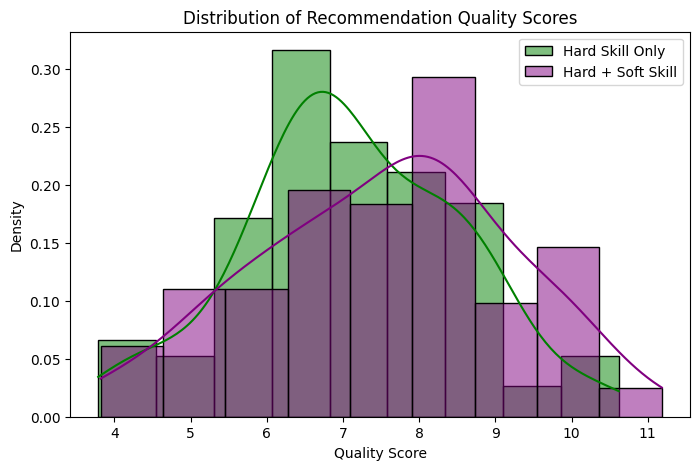

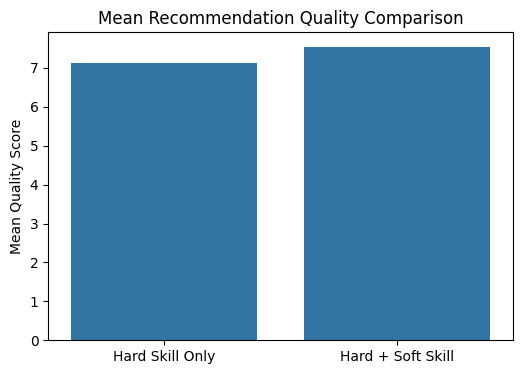

In [11]:
# ============================================================
# HYPOTHESIS TESTING (A/B Testing 3)
# ============================================================

from scipy.stats import ttest_ind

# Independent t-test for comparing means
t_statistic, p_value_ab3 = ttest_ind(hard_skill_group, combined_group, equal_var=False) # Assuming unequal variances

print("\n===== A/B Test 3: TEST RESULT =====")
print(f"T-statistic: {t_statistic:.2f}")
print(f"P-value: {p_value_ab3:.4f}")

alpha_ab3 = 0.05
print("\n===== A/B Test 3: DECISION =====")
if p_value_ab3 < alpha_ab3:
    print("Reject H0: There is a statistically significant difference in recommendation quality.")
    if combined_group.mean() > hard_skill_group.mean():
        print("Adding soft skills improves recommendation quality.")
    else:
        print("Hard skills alone result in better recommendation quality.")
else:
    print("Fail to Reject H0: No statistically significant difference in recommendation quality.")

# ============================================================
# BUSINESS INTERPRETATION (A/B Testing 3)
# ============================================================
mean_hard_skill = hard_skill_group.mean()
mean_combined_skill = combined_group.mean()

mean_improvement_ab3 = ((mean_combined_skill - mean_hard_skill) / mean_hard_skill) * 100
print(f"\nMean Hard Skill Quality: {mean_hard_skill:.2f}")
print(f"Mean Hard+Soft Skill Quality: {mean_combined_skill:.2f}")
print(f"Mean Quality Improvement: {mean_improvement_ab3:.2f}%")

# ============================================================
# VISUALIZATION (A/B Testing 3)
# ============================================================

plt.figure(figsize=(8, 5))
sns.histplot(hard_skill_group, color='green', label='Hard Skill Only', kde=True, stat='density', alpha=0.5)
sns.histplot(combined_group, color='purple', label='Hard + Soft Skill', kde=True, stat='density', alpha=0.5)
plt.title('Distribution of Recommendation Quality Scores')
plt.xlabel('Quality Score')
plt.ylabel('Density')
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(x=['Hard Skill Only', 'Hard + Soft Skill'], y=[mean_hard_skill, mean_combined_skill])
plt.title('Mean Recommendation Quality Comparison')
plt.ylabel('Mean Quality Score')
plt.show()

# A/B Testing 4 : Skill Gap Analysis vs Tanpa Skill Gap Analysis

In [13]:
print("""
Business Problem:

Apakah Skill Gap Analysis
mendorong pengguna mengambil kursus
yang direkomendasikan?
""")


Business Problem:

Apakah Skill Gap Analysis
mendorong pengguna mengambil kursus
yang direkomendasikan?



In [15]:
# Placeholder for actual enrollment rates from A/B Testing 4 data
# Example: If 'enrollment_group_A' and 'enrollment_group_B' are your raw data
# rate_A = sum(enrollment_group_A) / len(enrollment_group_A)
# rate_B = sum(enrollment_group_B) / len(enrollment_group_B)

# Using sample values for demonstration
rate_A = 0.15 # Example: 15% enrollment rate for Group A (Tanpa Skill Gap Analysis)
rate_B = 0.18 # Example: 18% enrollment rate for Group B (Skill Gap Analysis)

lift = (
    (rate_B - rate_A)
    / rate_A
) * 100

print(
    f"Enrollment Lift : {lift:.2f}%"
)

Enrollment Lift : 20.00%


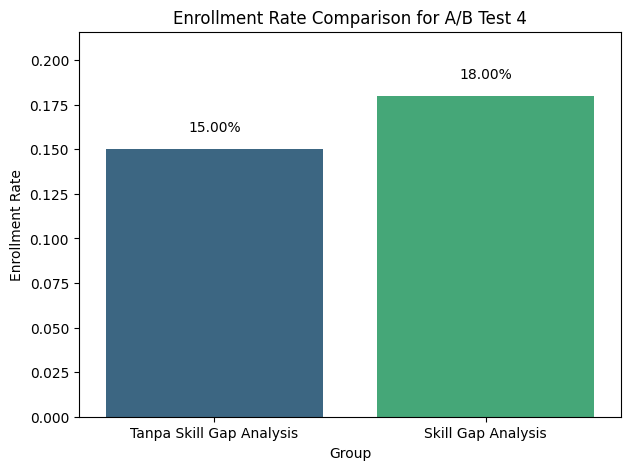

In [17]:
# ============================================================
# VISUALIZATION (A/B Testing 4)
# ============================================================

plt.figure(figsize=(7, 5))
sns.barplot(x=['Tanpa Skill Gap Analysis', 'Skill Gap Analysis'], y=[rate_A, rate_B], hue=['Tanpa Skill Gap Analysis', 'Skill Gap Analysis'], palette='viridis', legend=False)
plt.title('Enrollment Rate Comparison for A/B Test 4')
plt.xlabel('Group')
plt.ylabel('Enrollment Rate')
plt.ylim(0, max(rate_A, rate_B) * 1.2) # Set y-limit to be slightly above the max rate

# Add text labels on top of the bars
for index, value in enumerate([rate_A, rate_B]):
    plt.text(index, value + 0.01, f'{value:.2%}', color='black', ha="center")

plt.show()